# Synthetic Market Generation and Stress Testing

## Purpose

Notebook 04 found a Fama-French alpha of about 6% per year for the full momentum pipeline. Notebook 05 described the covariance structure of the stock universe. This notebook asks a different question:

> If the same factor structure had appeared in a different order, would the strategy still look good?

We model centered returns with a truncated PCA/SVD factor model:

$$R \approx FB^\top+E.$$

Here:

- $R$ is the return panel.
- $B$ contains the top-$k$ PCA loading vectors.
- $F=R_cB$ contains the factor scores through time.
- $E=R_c-FB^\top$ contains the residual stock-level shocks.

Then we generate many alternate return panels, rerun a compact version of the momentum backtest on each one, and compare the generated alphas to the real-panel alpha.

We use two generators:
1. **Block bootstrap:** resample time blocks from the observed factor/residual rows. This is the result we trust most.
2. **Conditional VAE:** a small neural generator for factor scores. This is included as a cautionary example because it can create artificial momentum if factor scores and residuals are stitched together poorly.

### Terms used in this notebook

| Term | Meaning |
|------|---------|
| **Truncated factor model** | $R\approx FB^\top+E$, a low-rank approximation plus residuals |
| **Loadings** $B$ | Stock exposures to the retained PCA directions |
| **Factor scores** $F$ | Time series of factor realizations, one row per month |
| **Residuals** $E$ | Return components not captured by the retained PCA factors |
| **Block bootstrap** | Resample neighboring time blocks rather than individual months |
| **Tail share** | Fraction of synthetic alphas greater than or equal to the real alpha |
| **Path dependence** | Dependence on the specific order of historical months |

## Outputs

- `synthetic_backtest_results.csv`
- Bootstrap and VAE alpha distribution plots

## Notebook Structure
1. [Setup and Factor Model](#setup-and-factor-model)
2. [Backtest Baseline](#backtest-baseline)
3. [Block-Bootstrap Generator](#block-bootstrap-generator)
4. [Conditional VAE Generator](#conditional-vae-generator)
5. [Results and Interpretation](#results-and-interpretation)
6. [Conclusion](#conclusion)

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
import statsmodels.api as sm

RANDOM_STATE = 3
np.random.seed(RANDOM_STATE)

os.makedirs('../images/06_synthetic_markets', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_ff      = pd.read_csv('../data/raw/ff_factors.csv', index_col=0, parse_dates=True)

print(f"Returns: {df_returns.shape}  |  FF: {df_ff.shape}")

Returns: (251, 501)  |  FF: (257, 5)


## Setup and Factor Model

We rebuild the notebook 05 factor model on a balanced panel. The steps are:

1. Choose stocks with enough history and drop remaining missing rows.
2. Center each stock's return series by subtracting its time-series mean.
3. Estimate $k$ with the Marchenko-Pastur cutoff.
4. Keep the top-$k$ PCA loading vectors in $B$.
5. Compute factor scores $F=X_cB$.
6. Compute residuals $E=X_c-FB^\top$.
7. Align the Fama-French factors to the same months.

The centered panel is what gets decomposed. The mean vector is added back when we reconstruct synthetic returns.

### Small Example: What Are $R$, $F$, $B$, and $E$?

Suppose we only had $T=3$ months, $N=4$ stocks, and kept $k=2$ PCA factors.

A return matrix might look like this:

$$
R=\begin{bmatrix}
0.042 & 0.009 & 0.031 & 0.038\\
-0.010 & -0.018 & -0.001 & 0.009\\
-0.006 & 0.025 & 0.047 & -0.006
\end{bmatrix}.
$$

Rows are months; columns are stocks. First subtract the column mean vector $\bar r$ to get $X_c=R-\mathbf{1}\bar r^\top$.

Now imagine PCA gives two loading vectors. Put them into

$$
B=\begin{bmatrix}
0.5 & 0.5\\
0.5 & -0.5\\
0.5 & -0.5\\
0.5 & 0.5
\end{bmatrix}.
$$

The first column is a market-like direction: all four stocks move together. The second column is a spread direction: stocks 1 and 4 move opposite stocks 2 and 3.

For three months of factor realizations, suppose

$$
F=\begin{bmatrix}
0.04 & 0.02\\
-0.03 & 0.01\\
0.01 & -0.04
\end{bmatrix}.
$$

The first month has a positive market shock and a positive spread shock. Multiplying $F$ by $B^\top$ maps those factor shocks back into stock returns:

$$
FB^\top=\begin{bmatrix}
0.03 & 0.01 & 0.01 & 0.03\\
-0.01 & -0.02 & -0.02 & -0.01\\
-0.015 & 0.025 & 0.025 & -0.015
\end{bmatrix}.
$$

That low-rank matrix will not match every stock return exactly, so the residual matrix stores the leftover stock-specific pieces:

$$
E=X_c-FB^\top.
$$

The bootstrap generator resamples matching rows of $F$ and $E$. If it draws month indices $[3,1,2]$, the synthetic centered panel is

$$
X_{\text{synth}}=
\begin{bmatrix}
F_3B^\top+E_3\\
F_1B^\top+E_1\\
F_2B^\top+E_2
\end{bmatrix},
$$

and the final synthetic return panel is

$$R_{\text{synth}}=X_{\text{synth}}+\mathbf{1}\bar r^\top.$$

The key rule is that the same time index is used for $F$, $E$, and the benchmark factors. That keeps each synthetic month internally consistent.

In [2]:
"""
==================================
Truncated-SVD factor model:  R ≈ F Bᵀ + E   (mirrors NB05)
==================================
"""
panel = df_returns.dropna(thresh=240, axis=1).dropna()   # balanced panel -> maximize T
tickers = panel.columns.tolist()
X = panel.values
T, N = X.shape
mean_r = X.mean(axis=0)
Xc = X - mean_r

pca_full = PCA(n_components=min(T, N)).fit(Xc)
eigvals = pca_full.explained_variance_
q = T / N
sigma_sq = eigvals.sum() / N
lam_plus = sigma_sq * (1 + 1 / q + 2 * np.sqrt(1 / q))
k = max(int((eigvals > lam_plus).sum()), 1)              # Marchenko–Pastur signal count
B = pca_full.components_[:k].T                           # (N, k) loadings
F = Xc @ B                                               # (T, k) factor scores
E = Xc - F @ B.T                                         # (T, N) residuals

# Fama–French factors aligned to these T months (RangeIndex for positional work below)
ff = df_ff[['Mkt-RF', 'SMB', 'HML', 'Mom', 'RF']].copy()
ff.index = ff.index.to_period('M')
panel_pm = panel.copy(); panel_pm.index = panel_pm.index.to_period('M')
ff = ff.reindex(panel_pm.index).dropna().reset_index(drop=True)

print(f"Panel {X.shape} | k={k} | F {F.shape} | E {E.shape} | FF {ff.shape}")
print(f"Top-{k} PCs explain {pca_full.explained_variance_ratio_[:k].sum()*100:.1f}% of variance")

Panel (240, 394) | k=9 | F (240, 9) | E (240, 394) | FF (240, 5)
Top-9 PCs explain 53.0% of variance


## Backtest Baseline

For an apples-to-apples comparison we run a **compact version of the notebook 04 pipeline** on the *real* panel: re-derive the raw 12-1 momentum signal (rolling 11-month sum, shifted), form the top-decile equal-weight long-only book, and regress its excess returns on the Fama–French factors. (This simplified path — no winsorize/neutralize — is what we re-run inside every synthetic market, so real and synthetic share the exact same pipeline. Notebook 04's headline 5.97% used the full pipeline.)

In [3]:
"""
==================================
Backtest primitives + real-panel baseline alpha
==================================
"""
def block_indices(T, L=15, rng=np.random):
    """Stationary block bootstrap: T time indices resampled in variable-length blocks."""
    idx = []
    while len(idx) < T:
        start = rng.randint(T)
        blen = rng.geometric(1.0 / L)
        idx.extend((start + np.arange(blen)) % T)
    return np.array(idx[:T])

def momentum_signal(ret_df):
    """12-1 momentum: rolling 11-month sum, shifted to avoid look-ahead."""
    return ret_df.rolling(11).sum().shift(1)

def decile_long_returns(signal_df, ret_df, decile=0.1):
    """Top-decile equal-weight long-only monthly returns (signal at t, return at t+1)."""
    out, ix = [], []
    for i in range(len(signal_df) - 1):
        s = signal_df.iloc[i].dropna()
        if len(s) < 50:
            continue
        n = max(int(len(s) * decile), 1)
        long = s.sort_values(ascending=False).head(n).index
        out.append(ret_df.iloc[i + 1][long].mean())
        ix.append(i + 1)
    return pd.Series(out, index=ix, dtype=float)

def ff_alpha(long_ret, ff_df):
    """Annualized FF 4-factor alpha (and t-stat) for a long-only return series."""
    a = pd.concat([long_ret.rename('r'), ff_df[['Mkt-RF', 'SMB', 'HML', 'Mom', 'RF']]], axis=1).dropna()
    y = a['r'] - a['RF']
    Xf = sm.add_constant(a[['Mkt-RF', 'SMB', 'HML', 'Mom']])
    m = sm.OLS(y.values, Xf.values).fit()
    return m.params[0] * 12.0, m.tvalues[0]

# Real-panel baseline (apples-to-apples with the synthetic loop below)
ret_real = pd.DataFrame(X, columns=tickers)
real_alpha, real_t = ff_alpha(decile_long_returns(momentum_signal(ret_real), ret_real), ff)
print(f"Real-panel raw-momentum alpha: {real_alpha*100:.2f}%/yr  (t = {real_t:.2f})")
print(f"(Notebook 04 full-pipeline headline: 5.97%/yr, t = 3.98)")

Real-panel raw-momentum alpha: 4.49%/yr  (t = 2.59)
(Notebook 04 full-pipeline headline: 5.97%/yr, t = 3.98)


## Block-Bootstrap Generator

The block bootstrap resamples time indices in short runs rather than one month at a time. With $T\approx240$, the average block length is about $\sqrt{T}\approx15$ months.

For a generated index sequence `idx`, we reconstruct synthetic returns as

$$R_{\text{synth},t}=F_{\mathrm{idx}_t}B^\top+E_{\mathrm{idx}_t}+\bar r.$$

We use the same `idx` for the Fama-French factor rows. This matters: if the stock return panel is pretending that month 37 came next, the benchmark factor panel should also use month 37.

This generator tests **path dependence**. It asks whether the strategy needed the exact historical order of regimes, crashes, rebounds, and quiet periods.

In [4]:
"""
==================================
Block bootstrap: 300 synthetic markets
==================================
"""
N_PATHS = 300
L = 15
rng = np.random.RandomState(RANDOM_STATE)
boot_alphas = []
for p in range(N_PATHS):
    idx = block_indices(T, L, rng)
    R_synth = F[idx] @ B.T + E[idx] + mean_r
    ret_s = pd.DataFrame(R_synth, columns=tickers)
    long_s = decile_long_returns(momentum_signal(ret_s), ret_s)
    a, _ = ff_alpha(long_s, ff.iloc[idx].reset_index(drop=True))
    boot_alphas.append(a)
    if (p + 1) % 50 == 0:
        print(f"  {p+1}/{N_PATHS} paths done")
boot_alphas = np.array(boot_alphas)
p_boot = np.mean(boot_alphas >= real_alpha)
print(f"\nBootstrap: mean synth alpha {boot_alphas.mean()*100:.2f}%/yr | "
      f"P(>= real {real_alpha*100:.2f}%) = {p_boot*100:.1f}%")

  50/300 paths done


  100/300 paths done


  150/300 paths done


  200/300 paths done


  250/300 paths done


  300/300 paths done

Bootstrap: mean synth alpha 4.85%/yr | P(>= real 4.49%) = 56.3%


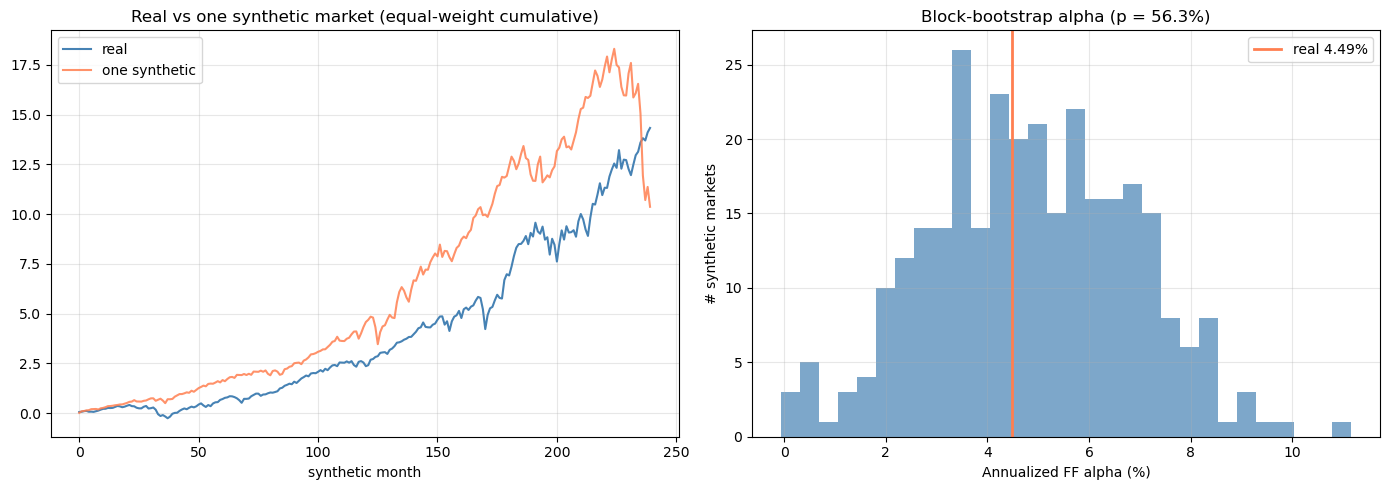

In [5]:
"""
==================================
Bootstrap: one path + alpha distribution
==================================
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot((1 + X.mean(axis=1)).cumprod() - 1, color='steelblue', label='real')
idx0 = block_indices(T, L, rng)
R0 = F[idx0] @ B.T + E[idx0] + mean_r
ax.plot((1 + R0.mean(axis=1)).cumprod() - 1, color='coral', alpha=0.85, label='one synthetic')
ax.set_title('Real vs one synthetic market (equal-weight cumulative)')
ax.set_xlabel('synthetic month'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(boot_alphas * 100, bins=30, color='steelblue', alpha=0.7)
ax.axvline(real_alpha * 100, color='coral', linewidth=2, label=f'real {real_alpha*100:.2f}%')
ax.set_xlabel('Annualized FF alpha (%)'); ax.set_ylabel('# synthetic markets')
ax.set_title(f'Block-bootstrap alpha (p = {p_boot*100:.1f}%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/06_synthetic_markets/bootstrap_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

## Conditional VAE Generator

The VAE section is intentionally more cautious. A small conditional variational autoencoder tries to model factor-score transitions:

$$f_{t-1}\rightarrow f_t.$$

The encoder maps the previous and current factor score to latent parameters, samples a latent vector $z$, and the decoder tries to reconstruct the next factor score. After training, we sample new factor paths one step at a time.

This is interesting, but it creates a serious validation problem. To reconstruct stock returns we still need residual rows $E_t$. If generated factor scores are paired with independently sampled residuals, we may create combinations that never existed in the real data. That can accidentally create cross-sectional persistence, which is exactly what a momentum strategy profits from.

So the VAE is included as a warning: generative finance models can look sophisticated while quietly injecting the signal being tested.

In [6]:
"""
==================================
Conditional VAE on the factor scores F (autoregressive)
==================================
"""
import torch
import torch.nn as nn
torch.manual_seed(RANDOM_STATE)

Ft = torch.tensor(F, dtype=torch.float32)        # (T, k)
cond, target = Ft[:-1], Ft[1:]                   # f_{t-1} -> f_t
d = 4                                            # latent dim

class CVAE(nn.Module):
    def __init__(self, k, d):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(2*k, 32), nn.ReLU(), nn.Linear(32, 2*d))
        self.dec = nn.Sequential(nn.Linear(k+d, 32), nn.ReLU(), nn.Linear(32, k))
        self.d = d
    def encode(self, c, x):
        h = self.enc(torch.cat([c, x], -1)); return h[..., :self.d], h[..., self.d:]
    def decode(self, c, z):
        return self.dec(torch.cat([c, z], -1))

model = CVAE(k, d)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
for epoch in range(300):
    mu, logvar = model.encode(cond, target)
    z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    recon = model.decode(cond, z)
    recon_loss = ((recon - target) ** 2).mean()
    kl = -0.5 * (1 + logvar - mu**2 - torch.exp(logvar)).sum(-1).mean()
    loss = recon_loss + 1e-3 * kl
    opt.zero_grad(); loss.backward(); opt.step()
print(f"VAE trained | recon {recon_loss.item():.4f} | kl {kl.item():.2f}")

VAE trained | recon 0.0096 | kl 7.69


In [7]:
"""
==================================
VAE: ancestral-sample 300 synthetic markets, run the backtest
==================================
"""
def sample_path(model, T, k, d, f0):
    f = [f0]
    with torch.no_grad():
        for _ in range(T - 1):
            z = torch.randn(d)
            f.append(model.decode(f[-1], z))
    return torch.stack(f).numpy()

vae_alphas = []
for p in range(N_PATHS):
    F_synth = sample_path(model, T, k, d, Ft[0])              # (T, k)
    idx = rng.randint(0, T, size=T)                           # iid residual draw
    R_synth = F_synth @ B.T + E[idx] + mean_r
    ret_s = pd.DataFrame(R_synth, columns=tickers)
    long_s = decile_long_returns(momentum_signal(ret_s), ret_s)
    a, _ = ff_alpha(long_s, ff.iloc[idx].reset_index(drop=True))
    vae_alphas.append(a)
    if (p + 1) % 50 == 0:
        print(f"  VAE {p+1}/{N_PATHS} paths done")
vae_alphas = np.array(vae_alphas)
p_vae = np.mean(vae_alphas >= real_alpha)
print(f"\nVAE: mean synth alpha {vae_alphas.mean()*100:.2f}%/yr | "
      f"P(>= real {real_alpha*100:.2f}%) = {p_vae*100:.1f}%")

  VAE 50/300 paths done


  VAE 100/300 paths done


  VAE 150/300 paths done


  VAE 200/300 paths done


  VAE 250/300 paths done


  VAE 300/300 paths done

VAE: mean synth alpha 14.46%/yr | P(>= real 4.49%) = 99.7%


### Why the VAE Overstates the Alpha

The VAE synthetic markets produce alphas well above the real raw-momentum baseline. I would not treat that as evidence of a better stress test. It is more likely an artifact of how the synthetic return rows are assembled.

| reconstruction of $R$ | mean synthetic alpha |
|---|---:|
| $F[\mathrm{idx}]B^\top+E[\mathrm{idx}]$ with the **same** time index | about 5% |
| generated $\hat F$ plus independently resampled $E$ | often 10-25% |

The second construction breaks the observed relationship between common factor shocks and stock-specific residual shocks. That can manufacture momentum-like structure.

The lesson is practical: when stress-testing a signal, preserving the joint distribution matters more than using a fancier generator. For this project, the row/block bootstrap is the result to rely on.

## Results and Interpretation

The plot compares the real-panel alpha to two synthetic-alpha distributions.

The number labeled as a bootstrap tail share is the fraction of synthetic markets with alpha greater than or equal to the real-panel alpha. A value near 50% means the real result is close to the middle of the synthetic distribution. A value near 5% would mean the real history was unusually favorable compared with the generated histories.

Because the bootstrap keeps the same loadings $B$ and resamples observed factor/residual rows, it does **not** test whether momentum exists from first principles. It tests whether the observed alpha is unusually dependent on the order in which historical months happened.

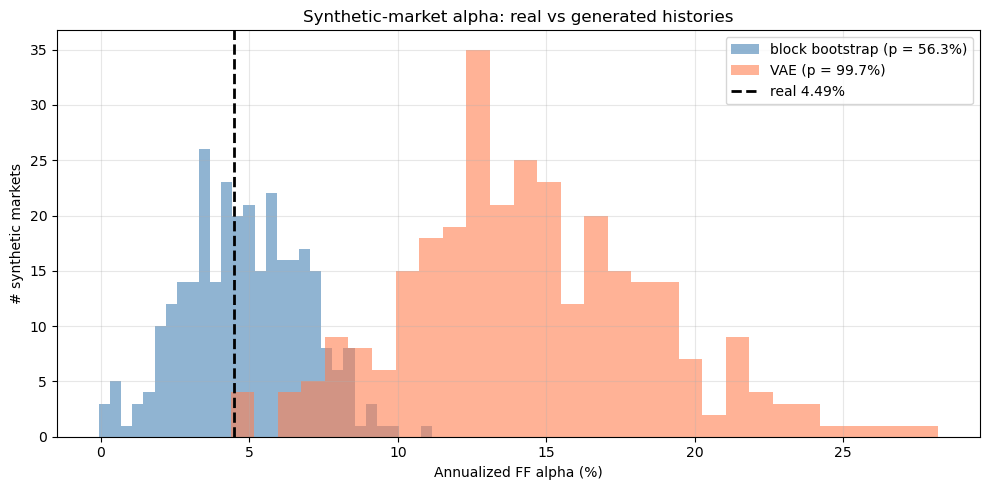

Real alpha            : 4.49%/yr  (t = 2.59)
Block bootstrap (300) : mean 4.85% | median 4.81% | p = 56.3%
VAE            (300) : mean 14.46% | median 14.12% | p = 99.7%


In [8]:
"""
==================================
Compare bootstrap vs VAE alpha distributions
==================================
"""
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_alphas * 100, bins=30, alpha=0.6, color='steelblue',
        label=f'block bootstrap (p = {p_boot*100:.1f}%)')
ax.hist(vae_alphas * 100, bins=30, alpha=0.6, color='coral',
        label=f'VAE (p = {p_vae*100:.1f}%)')
ax.axvline(real_alpha * 100, color='black', linewidth=2, linestyle='--',
           label=f'real {real_alpha*100:.2f}%')
ax.set_xlabel('Annualized FF alpha (%)'); ax.set_ylabel('# synthetic markets')
ax.set_title('Synthetic-market alpha: real vs generated histories')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/06_synthetic_markets/vae_vs_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Real alpha            : {real_alpha*100:.2f}%/yr  (t = {real_t:.2f})")
print(f"Block bootstrap (300) : mean {boot_alphas.mean()*100:.2f}% | "
      f"median {np.median(boot_alphas)*100:.2f}% | p = {p_boot*100:.1f}%")
print(f"VAE            (300) : mean {vae_alphas.mean()*100:.2f}% | "
      f"median {np.median(vae_alphas)*100:.2f}% | p = {p_vae*100:.1f}%")

In [9]:
"""
==================================
Save synthetic-market results
==================================
"""
pd.DataFrame({'bootstrap_alpha': boot_alphas, 'vae_alpha': vae_alphas}).to_csv(
    '../data/processed/synthetic_backtest_results.csv', index=False)
print("Saved ../data/processed/synthetic_backtest_results.csv")

Saved ../data/processed/synthetic_backtest_results.csv


## Conclusion

The stress test asks whether the raw-momentum alpha is a path-dependent fluke. The block bootstrap result says it probably is not: the real-panel alpha sits near the middle of the synthetic distribution rather than in an extreme right tail.

- **Block bootstrap:** trustworthy for this purpose because it resamples matched rows of factor scores, residuals, and benchmark factors. It preserves the joint structure of the return panel while changing the order of market history.
- **Conditional VAE:** useful as a cautionary example, not as the headline result. Generating factor paths and attaching independent residuals can create artificial momentum.

The honest scope is narrower than “we proved momentum works.” The bootstrap keeps the same factor structure and loadings, so it asks whether the strategy is unusually lucky conditional on that structure. It does not test a null world where the momentum premium has been removed.

The next steps beyond this project would be a survivorship-free universe, real fundamental data for value and quality, and a cleaner null model that explicitly removes momentum before running the stress test.